---

## NOTEBOOK 7 (8000) — Transfer Learning (PANNs embeddings, full dataset)

---

### Objectif

Extraire des embeddings audio 2048-dim via **CNN14 préentraîné** (PANNs / AudioSet) et
comparer leur pouvoir discriminant aux features librosa maison (351-dim, NB2) pour la
classification genre_top sur FMA Small.

---

### Plan du notebook

| Cellule | Section | Contenu |
|---------|---------|---------|
| C4 | 1.1. Imports | Librairies audio, ML, système |
| C5 | 1.2. Configuration | Seed, device, mode prototype/full, baseline NB5 |
| C6 | 2. Chemins & install | Paths relatifs, installation `panns_inference` |
| C7 | 3. Chargement | `features_V2.csv` — labels + artist_name (source vérité) |
| C8 | 4. Prototype | Sélection 1 000 pistes stratifiées (125/genre) |
| C9 | 5. Init PANNs | Chargement CNN14, test signal synthétique |
| C10 | 5.1. Extraction | Embeddings 2048-dim, checkpoints /200 pistes |
| C11 | 5.bis Validation | Quality gates : shape, NaN, variance, norme L2 |
| C12 | 6. Split | GroupShuffleSplit artiste (seed=42, test_size=0.2) |
| C13 | 7.1. XGBoost | XGBoost sur embeddings PANNs (sans scaler) |
| C14 | 7.2. MLP | MLP 3 couches (BatchNorm, Dropout) sur embeddings |
| C15 | 8. Comparaison | PANNs vs baseline features_V2 (barplot + tableau) |
| C16 | 8.bis Confusion | Matrice de confusion meilleur modèle |
| C17 | 9. CSV | Sauvegarde `results_nb7.csv` (15 colonnes protocole) |
| C18 | 10. Scaling | Instructions passage 8 000 pistes |
| C19 | 11. Décisions | Constantes figées transmises au rapport |

---

### Hypothèse testable

> Les embeddings PANNs (2048-dim, préentraînés sur AudioSet 527 classes) produiront
> un F1 macro supérieur au plafond tabulaire ~0.502 observé en NB3/NB5,
> particulièrement sur les genres acoustiquement ambigus (Pop, Experimental, International).

---

### Décisions prises dans ce notebook (résumé)

- **Modèle PANNs** : CNN14 (AudioSet, 2048-dim) — meilleur compromis qualité/vitesse
- **Prototype** : 1 000 pistes stratifiées (125/genre), extensible à 8 000 via flag
- **Audio** : mono, sr=22 050 Hz, fenêtre 30s centrée (identique NB2)
- **Split** : GroupShuffleSplit artiste, random_state=42 — aligné NB3/NB5
- **Checkpoint** : sauvegarde toutes les 200 pistes → reprise sans réextraction
- **Modèles** : XGBoost (sans scaler) + MLP 3 couches (avec StandardScaler)

---

### Fichiers produits

| Fichier | Contenu |
|---------|---------|
| `outputs/resultats/results_nb7.csv` | Résultats protocole (15 colonnes) |
| `outputs/transfer_learning/embeddings_panns.pkl` | Embeddings 2048-dim par piste |
| `outputs/transfer_learning/embeddings_panns_checkpoint.pkl` | Checkpoint reprise |
| `outputs/transfer_learning/confusion_matrix_panns.png` | Matrice de confusion |
| `outputs/transfer_learning/mlp_panns_curves.png` | Courbes entraînement MLP |
| `outputs/transfer_learning/panns_vs_baseline.png` | Barplot comparatif |
| `outputs/transfer_learning/decisions_nb7.json` | Décisions figées |

---

In [1]:
# C4
# 1.1. Imports

import sys
import ast
import warnings
import pickle
import time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, balanced_accuracy_score
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GroupKFold, GridSearchCV

warnings.filterwarnings('ignore')
print("Imports OK")

Imports OK


In [2]:
# C5
# 1.2. Configuration & device

# --- Reproductibilité ---
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# --- Prototype vs Full ---
PROTOTYPE         = False     # True = 1 000 pistes | False = 8 000 pistes
N_PER_GENRE       = 125      # pistes par genre en mode prototype
CHECKPOINT_EVERY  = 200      # sauvegarde intermédiaire toutes les N pistes

# --- Audio ---
AUDIO_SR       = 22050
AUDIO_DURATION = 30          # secondes (identique NB2)
AUDIO_MONO     = True

# --- Split ---
TEST_SIZE  = 0.2
ML_THRESH  = 100             # seuil sous-genres (cohérence NB5)

# --- Baseline NB5 (lecture dynamique depuis CSV) ---
_res_nb5 = pd.read_csv(Path.cwd() / "outputs" / "resultats" / "results_nb5.csv")
_row_nb5 = _res_nb5[_res_nb5["model"].str.contains("top1|genre_top", regex=True)].iloc[0]
BASELINE_F1  = _row_nb5["f1_test"]
BASELINE_ACC = _row_nb5["acc_test"]
BASELINE_BAL = _row_nb5["bal_acc_test"]

# --- Versions ---
print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")
print(f"\nMode : {'PROTOTYPE (' + str(N_PER_GENRE) + ' pistes/genre)' if PROTOTYPE else 'FULL (8 000 pistes)'}  |  Device : {device}")

Device : cuda
Python  : 3.12.10
PyTorch : 2.10.0+cu128
NumPy   : 2.3.5
Pandas  : 3.0.1

Mode : FULL (8 000 pistes)  |  Device : cuda


In [3]:
# C6
# 2. Chemins relatifs + installation PANNs

BASE            = Path.cwd()
FEATURES_V2_CSV = BASE / "outputs" / "features" / "features_V2.csv"
AUDIO_DIR       = BASE / "data" / "raw" / "fma_small" / "fma_small"
OUTPUT_DIR      = BASE / "outputs"
RESULTS_DIR     = OUTPUT_DIR / "resultats"
TRANSFER_DIR    = OUTPUT_DIR / "transfer_learning"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
TRANSFER_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDINGS_PKL    = TRANSFER_DIR / "embeddings_panns.pkl"
CHECKPOINT_PKL    = TRANSFER_DIR / "embeddings_panns_checkpoint.pkl"

# Vérifications préalables
assert FEATURES_V2_CSV.exists(), f"features_V2.csv introuvable : {FEATURES_V2_CSV}"
assert AUDIO_DIR.exists(),       f"Répertoire audio introuvable : {AUDIO_DIR}"

mp3_count = len(list(AUDIO_DIR.rglob("*.mp3")))
print(f"features_V2.csv : OK")
print(f"AUDIO_DIR       : {AUDIO_DIR}")
print(f"MP3 trouvés     : {mp3_count:,}  (attendu : 8 000)")

# Installation PANNs (idempotente)
print("\nInstallation panns_inference...")
import subprocess
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "panns_inference", "-q"],
    capture_output=True, text=True
)
if result.returncode == 0:
    print("panns_inference : OK")
else:
    print("Erreur installation :", result.stderr[:200])

# Import après installation
try:
    from panns_inference import AudioTagging
    print("Import panns_inference : OK")
except ImportError as e:
    print(f"Import failed : {e}")
    print("Relancez la cellule ou installez manuellement : pip install panns_inference")

features_V2.csv : OK
AUDIO_DIR       : c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\data\raw\fma_small\fma_small
MP3 trouvés     : 8,000  (attendu : 8 000)

Installation panns_inference...
panns_inference : OK
Import panns_inference : OK


In [4]:
# C7
# 3. Chargement — source unique : features_V2.csv

df_full = pd.read_csv(FEATURES_V2_CSV)

# Colonnes meta
META_COLS = ['track_id', 'track_id_int', 'genre_top', 'artist_name',
             'genres_decoded', 'genres', 'n_subgenres', 'mismatch',
             'mismatch_calc', 'track_title', 'year', 'duration', 'bit_rate']
META_COLS = [c for c in META_COLS if c in df_full.columns]
FEATURE_COLS = [c for c in df_full.columns if c not in META_COLS]

print(f"Pistes totales    : {len(df_full):,}")
print(f"Colonnes features : {len(FEATURE_COLS)}  (attendu : 351)")
print(f"Genres            : {sorted(df_full['genre_top'].unique())}")
print(f"Artistes uniques  : {df_full['artist_name'].nunique():,}")

# Distribution par genre
print("\nDistribution genre_top :")
print(df_full['genre_top'].value_counts().sort_index().to_string())

# Chemin MP3 par track_id
def get_mp3_path(track_id: int) -> Path:
    """Retourne le chemin MP3 FMA pour un track_id donné."""
    tid_str  = f"{track_id:06d}"
    subdir   = tid_str[:3]
    return AUDIO_DIR / subdir / f"{tid_str}.mp3"""

# Vérification sur 5 exemples
sample_ids = df_full['track_id'].head(5).tolist()
print("\nVérification chemins MP3 :")
for tid in sample_ids:
    p = get_mp3_path(int(tid))
    print(f"  {tid:6d} → {p.name}  exists={p.exists()}")

Pistes totales    : 7,994
Colonnes features : 351  (attendu : 351)
Genres            : ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']
Artistes uniques  : 2,304

Distribution genre_top :
genre_top
Electronic        999
Experimental      999
Folk             1000
Hip-Hop           997
Instrumental     1000
International    1000
Pop              1000
Rock              999

Vérification chemins MP3 :
       2 → 000002.mp3  exists=True
       5 → 000005.mp3  exists=True
      10 → 000010.mp3  exists=True
     140 → 000140.mp3  exists=True
     141 → 000141.mp3  exists=True


In [5]:
# C8
# 4. Sélection prototype — 1 000 pistes stratifiées (125/genre)

if PROTOTYPE:
    rng = np.random.RandomState(SEED)
    selected_parts = []
    for genre, gdf in df_full.groupby('genre_top'):
        n = min(N_PER_GENRE, len(gdf))
        sampled = gdf.sample(n=n, random_state=rng)
        selected_parts.append(sampled)
    df = pd.concat(selected_parts).reset_index(drop=True)
    print(f"Mode PROTOTYPE : {len(df):,} pistes sélectionnées")
else:
    df = df_full.copy()
    print(f"Mode FULL : {len(df):,} pistes")

print("\nDistribution prototype :")
print(df['genre_top'].value_counts().sort_index().to_string())

# Vérification que tous les MP3 sont accessibles
print("\nVérification accessibilité MP3 (échantillon 20 pistes)...")
sample_check = df.sample(min(20, len(df)), random_state=SEED)
missing = []
for _, row in sample_check.iterrows():
    p = get_mp3_path(int(row['track_id']))
    if not p.exists():
        missing.append(row['track_id'])

if missing:
    print(f"⚠️  MP3 manquants : {missing}")
    print("   → Vérifiez AUDIO_DIR")
else:
    print(f"✅  Tous les MP3 accessibles (échantillon n={len(sample_check)})")

Mode FULL : 7,994 pistes

Distribution prototype :
genre_top
Electronic        999
Experimental      999
Folk             1000
Hip-Hop           997
Instrumental     1000
International    1000
Pop              1000
Rock              999

Vérification accessibilité MP3 (échantillon 20 pistes)...
✅  Tous les MP3 accessibles (échantillon n=20)


In [6]:
# C9
# 5. Initialisation du modèle PANNs — CNN14

# Le premier appel télécharge les poids CNN14 (~200 MB) et les met en cache
# Les appels suivants chargent depuis le cache local
print("Chargement CNN14 (PANNs)...")
print("→ Premier appel : téléchargement ~200 MB (une seule fois)")

at = AudioTagging(checkpoint_path=None, device=str(device))
print("CNN14 chargé ✅")
print(f"Device utilisé : {device}")

# Test sur un signal synthétique (validation du pipeline)
dummy_audio = np.zeros((1, AUDIO_SR * 3), dtype=np.float32)   # 3s silence
with torch.no_grad():
    clipwise_out, embedding = at.inference(dummy_audio)
print(f"\nTest pipeline :")
print(f"  Input shape         : {dummy_audio.shape}")
print(f"  Embedding shape     : {embedding.shape}  (attendu : (1, 2048))")
print(f"  Clipwise out shape  : {clipwise_out.shape}  (AudioSet 527 classes)")
EMBED_DIM = embedding.shape[1]
print(f"  Embedding dim       : {EMBED_DIM}")

Chargement CNN14 (PANNs)...
→ Premier appel : téléchargement ~200 MB (une seule fois)
Checkpoint path: C:\Users\xiabi/panns_data/Cnn14_mAP=0.431.pth
GPU number: 1
CNN14 chargé ✅
Device utilisé : cuda

Test pipeline :
  Input shape         : (1, 66150)
  Embedding shape     : (1, 2048)  (attendu : (1, 2048))
  Clipwise out shape  : (1, 527)  (AudioSet 527 classes)
  Embedding dim       : 2048


In [7]:
# C10
# 5.1. Extraction PANNs — avec checkpoint toutes les 200 pistes

import librosa

# Chargement checkpoint existant (reprise)
if CHECKPOINT_PKL.exists():
    with open(CHECKPOINT_PKL, 'rb') as f:
        embeddings_dict = pickle.load(f)
    print(f"Checkpoint chargé : {len(embeddings_dict):,} pistes déjà extraites ✅")
else:
    embeddings_dict = {}
    print("Pas de checkpoint — extraction depuis zéro")

# Pistes restantes à extraire
track_ids_todo = [
    int(row['track_id']) for _, row in df.iterrows()
    if int(row['track_id']) not in embeddings_dict
]
print(f"Pistes à extraire : {len(track_ids_todo):,}  (déjà faites : {len(embeddings_dict):,})")

errors = []
t_start = time.time()

for i, track_id in enumerate(tqdm(track_ids_todo, desc="Extraction PANNs")):
    mp3_path = get_mp3_path(track_id)

    try:
        # Chargement audio : 30s centrées
        y_full, _ = librosa.load(str(mp3_path), sr=AUDIO_SR, mono=AUDIO_MONO)
        total_samples = len(y_full)
        target_samples = AUDIO_SR * AUDIO_DURATION

        if total_samples >= target_samples:
            # Centre la fenêtre
            start = (total_samples - target_samples) // 2
            y = y_full[start : start + target_samples]
        else:
            # Padding si trop court (rare dans FMA Small)
            y = np.pad(y_full, (0, target_samples - total_samples))

        # Extraction embedding PANNs
        y_input = y[np.newaxis, :]   # (1, samples)
        with torch.no_grad():
            _, emb = at.inference(y_input)
        embeddings_dict[track_id] = emb[0]   # (2048,)

    except Exception as e:
        errors.append((track_id, str(e)))
        embeddings_dict[track_id] = np.zeros(EMBED_DIM, dtype=np.float32)

    # Checkpoint toutes les CHECKPOINT_EVERY pistes
    if (i + 1) % CHECKPOINT_EVERY == 0:
        with open(CHECKPOINT_PKL, 'wb') as f:
            pickle.dump(embeddings_dict, f)
        elapsed = time.time() - t_start
        rate    = (i + 1) / elapsed
        remaining = (len(track_ids_todo) - i - 1) / rate if rate > 0 else 0
        tqdm.write(f"  Checkpoint sauvegardé ({i+1}/{len(track_ids_todo)}) — "
                   f"{elapsed:.0f}s écoulées, ~{remaining:.0f}s restantes")

# Sauvegarde finale
with open(CHECKPOINT_PKL, 'wb') as f:
    pickle.dump(embeddings_dict, f)
with open(EMBEDDINGS_PKL, 'wb') as f:
    pickle.dump(embeddings_dict, f)

elapsed_total = time.time() - t_start
print(f"\nExtraction terminée en {elapsed_total:.0f}s")
print(f"Pistes extraites : {len(embeddings_dict):,}")
print(f"Erreurs          : {len(errors)}")
if errors:
    print("Détail erreurs (5 premières) :")
    for tid, err in errors[:5]:
        print(f"  track_id={tid} : {err}")

Checkpoint chargé : 7,994 pistes déjà extraites ✅
Pistes à extraire : 0  (déjà faites : 7,994)


Extraction PANNs: 0it [00:00, ?it/s]



Extraction terminée en 0s
Pistes extraites : 7,994
Erreurs          : 0


In [8]:
# C11
# 5.bis Validation embeddings (shape, NaN, variance, séparabilité)

# Construction matrice X_emb alignée avec df
valid_ids = [int(row['track_id']) for _, row in df.iterrows()
             if int(row['track_id']) in embeddings_dict]
missing_ids = [int(row['track_id']) for _, row in df.iterrows()
               if int(row['track_id']) not in embeddings_dict]

print(f"Embeddings disponibles : {len(valid_ids):,} / {len(df):,}")
if missing_ids:
    print(f"Manquants : {missing_ids[:10]}...")

df_emb = df[df['track_id'].astype(int).isin(valid_ids)].copy().reset_index(drop=True)
X_emb  = np.stack([embeddings_dict[int(tid)] for tid in df_emb['track_id']])
y_emb  = df_emb['genre_top'].astype(str).values

print(f"\nX_emb shape : {X_emb.shape}  (attendu : n × 2048)")
print(f"y_emb shape : {y_emb.shape}")

# Quality gates
nan_count  = np.isnan(X_emb).sum()
zero_rows  = (X_emb.sum(axis=1) == 0).sum()   # pistes en erreur → embedding nul
var_global = X_emb.var(axis=0).mean()

print(f"\n=== QUALITY GATES EMBEDDINGS ===")
print(f"NaN values      : {nan_count}   (attendu : 0)")
print(f"Embeddings nuls : {zero_rows}   (pistes en erreur — attendu : 0)")
print(f"Variance mean   : {var_global:.4f}  (> 0 attendu)")

assert nan_count == 0,  "NaN détectés dans les embeddings !"
assert var_global > 0,  "Embeddings constants — problème d'extraction !"
print("Quality gates : ✅ PASS")

# Distribution de l'énergie (norme L2 par piste)
norms = np.linalg.norm(X_emb, axis=1)
print(f"\nNorme L2 embeddings — mean={norms.mean():.2f}, std={norms.std():.2f}, "
      f"min={norms.min():.2f}, max={norms.max():.2f}")

# Variance par genre (séparabilité grossière)
print("\nVariance inter-genre (norme moyenne par genre) :")
for genre in sorted(np.unique(y_emb)):
    mask = y_emb == genre
    print(f"  {genre:<15s} : norme mean = {norms[mask].mean():.2f}")

Embeddings disponibles : 7,994 / 7,994

X_emb shape : (7994, 2048)  (attendu : n × 2048)
y_emb shape : (7994,)

=== QUALITY GATES EMBEDDINGS ===
NaN values      : 0   (attendu : 0)
Embeddings nuls : 0   (pistes en erreur — attendu : 0)
Variance mean   : 0.0290  (> 0 attendu)
Quality gates : ✅ PASS

Norme L2 embeddings — mean=12.10, std=1.26, min=9.32, max=20.72

Variance inter-genre (norme moyenne par genre) :
  Electronic      : norme mean = 12.39
  Experimental    : norme mean = 12.18
  Folk            : norme mean = 12.10
  Hip-Hop         : norme mean = 11.91
  Instrumental    : norme mean = 11.90
  International   : norme mean = 12.91
  Pop             : norme mean = 11.72
  Rock            : norme mean = 11.70


In [9]:
# C12
# 6. Split — GroupShuffleSplit artiste (aligné NB3/NB5)

groups_emb = df_emb['artist_name'].astype(str).values

# Chargement indices NB5 si disponibles (source de vérité commune)
TRAIN_IDX_NPY = OUTPUT_DIR / 'train_idx.npy'
TEST_IDX_NPY  = OUTPUT_DIR / 'test_idx.npy'

# Note : les indices NB5 portent sur df_full (8000 pistes)
# Ici on travaille sur df_emb (sous-ensemble) → on recrée un split local
# cohérent (même paramètres) et on sauvegarde

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
train_idx_emb, test_idx_emb = next(gss.split(X_emb, y_emb, groups=groups_emb))

X_train_emb, X_test_emb   = X_emb[train_idx_emb],  X_emb[test_idx_emb]
y_train_emb, y_test_emb   = y_emb[train_idx_emb],  y_emb[test_idx_emb]
groups_train               = groups_emb[train_idx_emb]

# Anti-leakage
train_artists = set(groups_emb[train_idx_emb])
test_artists  = set(groups_emb[test_idx_emb])
overlap       = train_artists & test_artists
assert len(overlap) == 0, f"LEAKAGE : {len(overlap)} artistes en commun !"

print(f"Train : {len(X_train_emb):,} pistes | Test : {len(X_test_emb):,} pistes")
print(f"Artistes train : {len(train_artists)} | Artistes test : {len(test_artists)}")
print(f"Overlap artistes : {len(overlap)} ✅")

# Distribution
dist = pd.DataFrame({
    'Train' : pd.Series(y_train_emb).value_counts(normalize=True).round(3),
    'Test'  : pd.Series(y_test_emb).value_counts(normalize=True).round(3),
})
print(f"\nDistribution genre_top :\n{dist}")

# LabelEncoder — réutilisé pour XGB et MLP
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_emb)
y_test_enc  = le.transform(y_test_emb)
print(f"\nClasses : {list(le.classes_)}")

Train : 6,477 pistes | Test : 1,517 pistes
Artistes train : 1843 | Artistes test : 461
Overlap artistes : 0 ✅

Distribution genre_top :
               Train   Test
Electronic     0.116  0.164
Experimental   0.124  0.131
Folk           0.136  0.078
Hip-Hop        0.118  0.154
Instrumental   0.128  0.112
International  0.116  0.164
Pop            0.135  0.084
Rock           0.128  0.112

Classes : ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']


In [10]:
# C13
# 7.1. XGBoost sur embeddings PANNs — GridSearchCV (protocole commun)
import time as time_mod

pipe_xgb_panns = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
    ("clf", XGBClassifier(
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        learning_rate=0.1,
        random_state=SEED,
        eval_metric='mlogloss',
        verbosity=0,
        n_jobs=-1,
    ))
])

param_grid = {
    'clf__n_estimators':     [100, 300, 500],
    'clf__max_depth':        [10, 20, 30],
    'clf__min_child_weight': [4, 8],
}

CV_FOLDS = 5
gkf = GroupKFold(n_splits=CV_FOLDS)
sw  = compute_sample_weight("balanced", y_train_enc)

grid_search = GridSearchCV(
    estimator=pipe_xgb_panns,
    param_grid=param_grid,
    cv=gkf,
    scoring='f1_macro',
    refit=True,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
)

n_combos = 1
for v in param_grid.values():
    n_combos *= len(v)
print(f"Grille : {n_combos} combinaisons x {CV_FOLDS} folds = {n_combos * CV_FOLDS} fits")
print(f"⏳ GridSearchCV en cours...")

start = time_mod.time()
grid_search.fit(X_train_emb, y_train_enc, groups=groups_train, clf__sample_weight=sw)
duration_grid = time_mod.time() - start

print(f"✅ GridSearchCV termine en {duration_grid:.1f}s")
print(f"Meilleurs parametres : {grid_search.best_params_}")
print(f"Meilleur F1 macro CV : {grid_search.best_score_:.4f}")

best_index = grid_search.best_index_
cv_results = grid_search.cv_results_
cv_scores = [cv_results[f'split{i}_test_score'][best_index] for i in range(CV_FOLDS)]
f1_cv_mean = np.mean(cv_scores)
f1_cv_std  = np.std(cv_scores)
print(f"Scores CV ({CV_FOLDS} folds) :")
for i, s in enumerate(cv_scores):
    print(f"  Fold {i+1} : {s:.4f}")
print(f"  Moyenne : {f1_cv_mean:.4f} +/- {f1_cv_std:.4f}")

pipe_xgb_panns = grid_search.best_estimator_
y_pred_xgb = le.inverse_transform(pipe_xgb_panns.predict(X_test_emb))

acc_xgb  = accuracy_score(y_test_emb, y_pred_xgb)
f1_xgb   = f1_score(y_test_emb, y_pred_xgb, average='macro', zero_division=0)
bal_xgb  = balanced_accuracy_score(y_test_emb, y_pred_xgb)

print(f"=== XGBoost PANNs (GridSearchCV) ===")
print(f"Accuracy          : {acc_xgb:.4f}")
print(f"F1 macro          : {f1_xgb:.4f}")
print(f"Balanced accuracy : {bal_xgb:.4f}")
print(f"{classification_report(y_test_emb, y_pred_xgb, zero_division=0)}")

Grille : 18 combinaisons x 5 folds = 90 fits
⏳ GridSearchCV en cours...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
✅ GridSearchCV termine en 2031.4s
Meilleurs parametres : {'clf__max_depth': 20, 'clf__min_child_weight': 4, 'clf__n_estimators': 300}
Meilleur F1 macro CV : 0.5904
Scores CV (5 folds) :
  Fold 1 : 0.6092
  Fold 2 : 0.5799
  Fold 3 : 0.5952
  Fold 4 : 0.5834
  Fold 5 : 0.5841
  Moyenne : 0.5904 +/- 0.0107
=== XGBoost PANNs (GridSearchCV) ===
Accuracy          : 0.6295
F1 macro          : 0.6091
Balanced accuracy : 0.6100
               precision    recall  f1-score   support

   Electronic       0.61      0.73      0.66       249
 Experimental       0.61      0.55      0.58       199
         Folk       0.55      0.67      0.60       119
      Hip-Hop       0.83      0.74      0.78       233
 Instrumental       0.48      0.55      0.51       170
International       0.78      0.69      0.73       249
          Pop       0.35      0.34      0.35       128
  

Entraînement MLP (50 epochs)...
  Epoch  10/50 | loss=0.5636 | train_acc=0.804 | val_acc=0.585 | val_f1=0.572
  Epoch  20/50 | loss=0.3079 | train_acc=0.893 | val_acc=0.563 | val_f1=0.548
  Epoch  30/50 | loss=0.1270 | train_acc=0.960 | val_acc=0.462 | val_f1=0.480
  Epoch  40/50 | loss=0.1044 | train_acc=0.963 | val_acc=0.515 | val_f1=0.515
  Epoch  50/50 | loss=0.0613 | train_acc=0.979 | val_acc=0.566 | val_f1=0.541

=== MLP PANNs ===
Accuracy          : 0.5656
F1 macro          : 0.5405
Balanced accuracy : 0.5443


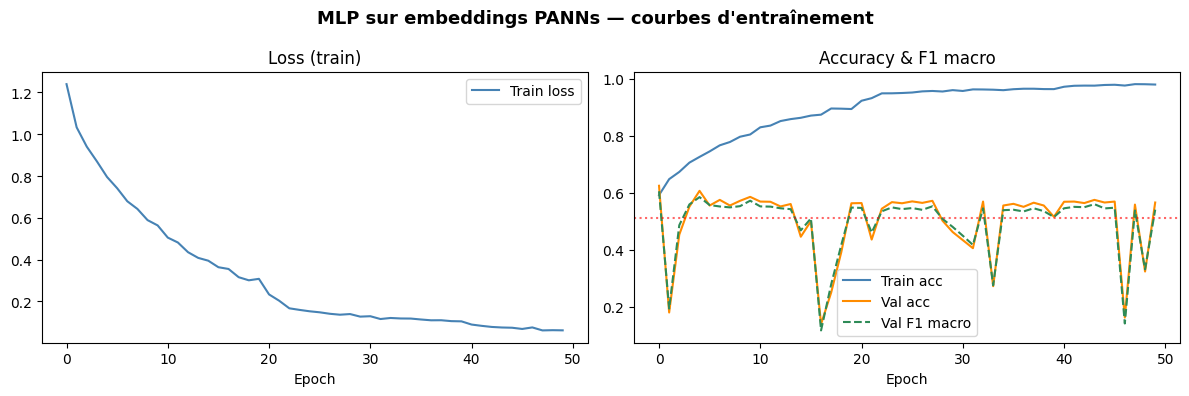

In [11]:
# C14
# 7.2. MLP sur embeddings PANNs (3 couches, BatchNorm, Dropout)

# Normalisation pour MLP (contrairement à XGB, les réseaux en ont besoin)
scaler_mlp = StandardScaler()
X_train_sc = scaler_mlp.fit_transform(X_train_emb)
X_test_sc  = scaler_mlp.transform(X_test_emb)

N_CLASSES_EMB = len(le.classes_)

class MLPClassifier(nn.Module):
    def __init__(self, input_dim=2048, hidden1=512, hidden2=128, n_classes=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden2, n_classes),
        )
    def forward(self, x):
        return self.net(x)

# DataLoaders
X_tr_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_tr_t = torch.tensor(y_train_enc, dtype=torch.long)
X_te_t = torch.tensor(X_test_sc,  dtype=torch.float32)
y_te_t = torch.tensor(y_test_enc,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=128, shuffle=False)

mlp = MLPClassifier(input_dim=EMBED_DIM, n_classes=N_CLASSES_EMB).to(device)
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

N_EPOCHS = 50
history = {"train_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

print(f"Entraînement MLP ({N_EPOCHS} epochs)...")
for epoch in range(N_EPOCHS):
    mlp.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = mlp(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct    += (out.argmax(1) == yb).sum().item()
        total      += len(yb)
    scheduler.step()

    # Validation
    mlp.eval()
    preds_val, trues_val = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            preds_val.extend(mlp(xb).argmax(1).cpu().numpy())
            trues_val.extend(yb.numpy())

    train_acc = correct / total
    val_acc   = accuracy_score(trues_val, preds_val)
    val_f1    = f1_score(trues_val, preds_val, average='macro', zero_division=0)

    history["train_loss"].append(total_loss / total)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:>3}/{N_EPOCHS} | loss={total_loss/total:.4f} "
              f"| train_acc={train_acc:.3f} | val_acc={val_acc:.3f} | val_f1={val_f1:.3f}")

# Résultats finaux MLP
y_pred_mlp_enc = np.array(preds_val)
y_pred_mlp     = le.inverse_transform(y_pred_mlp_enc)
acc_mlp = accuracy_score(y_test_emb, y_pred_mlp)
f1_mlp  = f1_score(y_test_emb, y_pred_mlp, average='macro', zero_division=0)
bal_mlp = balanced_accuracy_score(y_test_emb, y_pred_mlp)

print(f"\n=== MLP PANNs ===")
print(f"Accuracy          : {acc_mlp:.4f}")
print(f"F1 macro          : {f1_mlp:.4f}")
print(f"Balanced accuracy : {bal_mlp:.4f}")

# Courbes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("MLP sur embeddings PANNs — courbes d'entraînement", fontsize=13, fontweight='bold')
axes[0].plot(history["train_loss"], label="Train loss", color="steelblue")
axes[0].set_title("Loss (train)"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history["train_acc"], label="Train acc", color="steelblue")
axes[1].plot(history["val_acc"],   label="Val acc",   color="darkorange")
axes[1].plot(history["val_f1"],    label="Val F1 macro", color="seagreen", linestyle="--")
axes[1].set_title("Accuracy & F1 macro"); axes[1].set_xlabel("Epoch"); axes[1].legend()
axes[1].axhline(BASELINE_F1, color='red', linestyle=':', alpha=0.6, label='Baseline NB5')
plt.tight_layout()
plt.savefig(TRANSFER_DIR / 'mlp_panns_curves.png', dpi=150)
plt.show()

=== COMPARAISON FINALE — PANNs vs Baseline ===
                   Modèle          Features  F1 macro  Accuracy  Bal. Acc
XGBoost features_V2 (NB5) 351-dim (librosa)    0.5100    0.5201    0.5140
      XGBoost PANNs (NB7)  2048-dim (CNN14)    0.6091    0.6295    0.6100
          MLP PANNs (NB7)  2048-dim (CNN14)    0.5405    0.5656    0.5443

Gain XGBoost PANNs vs baseline : +0.0991 pts F1 macro
Gain MLP PANNs vs baseline      : +0.0305 pts F1 macro

Hypothèse confirmée : embeddings PANNs > features librosa maison


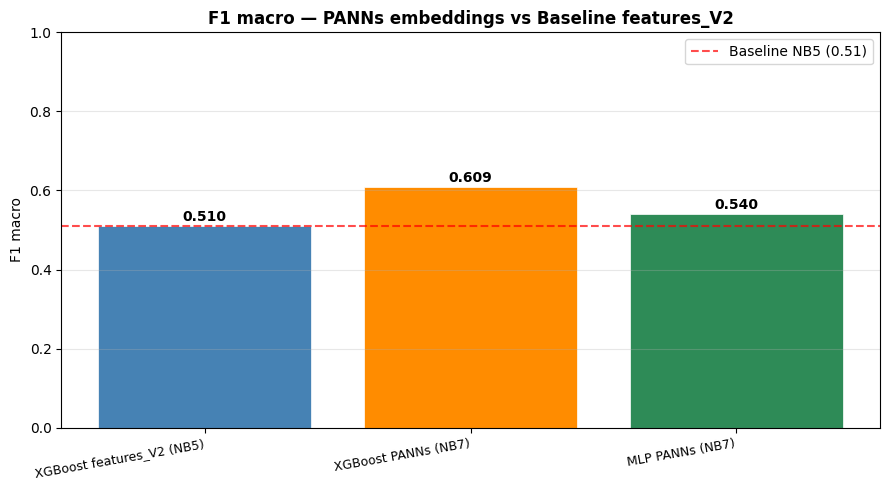

In [12]:
# C15
# 8. Comparaison PANNs vs baseline features_V2 (NB5)

results_comparison = pd.DataFrame([
    {
        'Modèle'    : 'XGBoost features_V2 (NB5)',
        'Features'  : '351-dim (librosa)',
        'F1 macro'  : BASELINE_F1,
        'Accuracy'  : BASELINE_ACC,
        'Bal. Acc'  : BASELINE_BAL,
    },
    {
        'Modèle'    : 'XGBoost PANNs (NB7)',
        'Features'  : '2048-dim (CNN14)',
        'F1 macro'  : round(f1_xgb, 4),
        'Accuracy'  : round(acc_xgb, 4),
        'Bal. Acc'  : round(bal_xgb, 4),
    },
    {
        'Modèle'    : 'MLP PANNs (NB7)',
        'Features'  : '2048-dim (CNN14)',
        'F1 macro'  : round(f1_mlp, 4),
        'Accuracy'  : round(acc_mlp, 4),
        'Bal. Acc'  : round(bal_mlp, 4),
    },
])

print("=== COMPARAISON FINALE — PANNs vs Baseline ===")
print(results_comparison.to_string(index=False))

delta_xgb = f1_xgb - BASELINE_F1
delta_mlp = f1_mlp - BASELINE_F1
print(f"\nGain XGBoost PANNs vs baseline : {delta_xgb:+.4f} pts F1 macro")
print(f"Gain MLP PANNs vs baseline      : {delta_mlp:+.4f} pts F1 macro")

if delta_xgb > 0 or delta_mlp > 0:
    print("\nHypothèse confirmée : embeddings PANNs > features librosa maison")
else:
    print("\nHypothèse non confirmée sur le prototype — à revérifier sur 8 000 pistes")
    print("   (biais possible : prototype 1 000 pistes, split local différent de NB5)")

# Barplot comparatif
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_comparison))
bars = ax.bar(x, results_comparison['F1 macro'], color=['steelblue', 'darkorange', 'seagreen'],
              edgecolor='white', linewidth=0.5)
ax.axhline(BASELINE_F1, color='red', linestyle='--', alpha=0.7, label=f'Baseline NB5 ({BASELINE_F1})')
for bar, val in zip(bars, results_comparison['F1 macro']):
    if val is not None:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_comparison['Modèle'], rotation=10, ha='right', fontsize=9)
ax.set_ylabel('F1 macro')
ax.set_title('F1 macro — PANNs embeddings vs Baseline features_V2', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(TRANSFER_DIR / 'panns_vs_baseline.png', dpi=150)
plt.show()

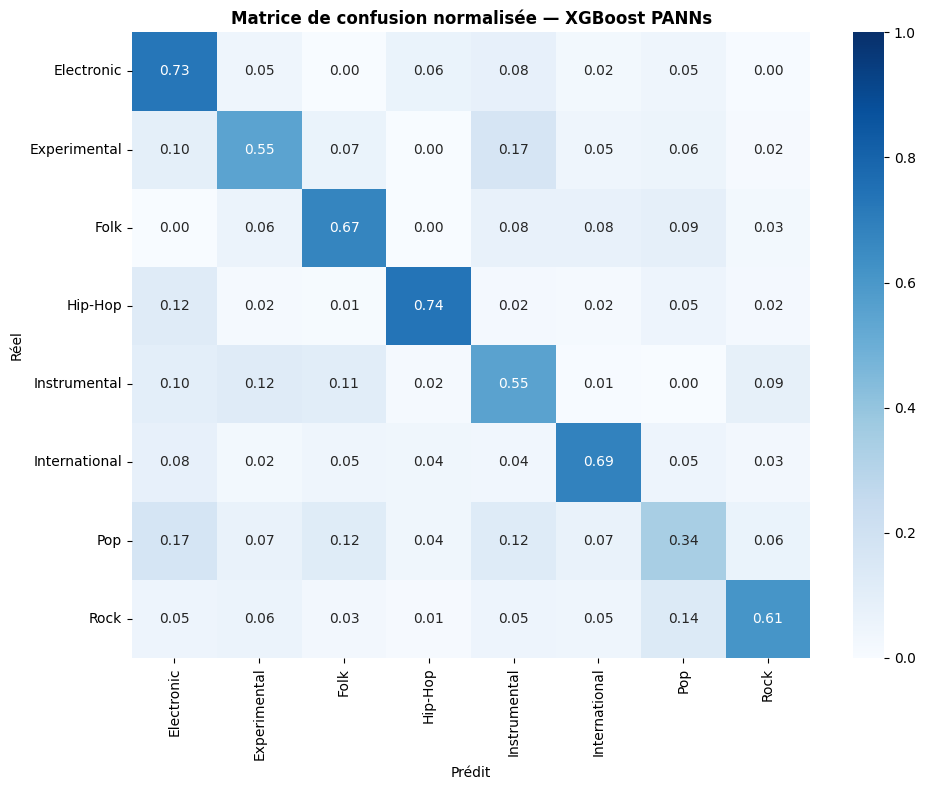

               precision    recall  f1-score   support

   Electronic       0.61      0.73      0.66       249
 Experimental       0.61      0.55      0.58       199
         Folk       0.55      0.67      0.60       119
      Hip-Hop       0.83      0.74      0.78       233
 Instrumental       0.48      0.55      0.51       170
International       0.78      0.69      0.73       249
          Pop       0.35      0.34      0.35       128
         Rock       0.71      0.61      0.66       170

     accuracy                           0.63      1517
    macro avg       0.61      0.61      0.61      1517
 weighted avg       0.64      0.63      0.63      1517



In [13]:
# C16
# 8.bis Matrice de confusion — meilleur modèle PANNs

best_preds  = y_pred_mlp if f1_mlp >= f1_xgb else y_pred_xgb
best_name   = "MLP PANNs" if f1_mlp >= f1_xgb else "XGBoost PANNs"
labels      = list(le.classes_)

cm      = confusion_matrix(y_test_emb, best_preds, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=labels, yticklabels=labels,
            cmap="Blues", ax=ax, vmin=0, vmax=1)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title(f"Matrice de confusion normalisée — {best_name}", fontweight="bold")
plt.tight_layout()
plt.savefig(TRANSFER_DIR / "confusion_matrix_panns.png", dpi=150)
plt.show()

print(classification_report(y_test_emb, best_preds, zero_division=0))

In [14]:
# C17
# 9. Sauvegarde CSV — format protocole (15 colonnes)

n_features_panns = EMBED_DIM  # 2048

results_nb7 = pd.DataFrame([
    {
        "model": "XGBoost_PANNs_genre_top",
        "f1_test": round(f1_xgb, 4),
        "acc_test": round(acc_xgb, 4),
        "bal_acc_test": round(bal_xgb, 4),
        "f1_cv_mean": round(f1_cv_mean, 4),
        "f1_cv_std": round(f1_cv_std, 4),
        "duration_s": round(duration_grid, 1),
        "seed": SEED,
        "split": "GroupShuffleSplit",
        "imputer": "median",
        "scaler": "RobustScaler",
        "n_features": n_features_panns,
        "n_train": len(X_train_emb),
        "n_test": len(X_test_emb),
        "dataset": "FMA_Small",
    },
    {
        "model": "MLP_PANNs_genre_top",
        "f1_test": round(f1_mlp, 4),
        "acc_test": round(acc_mlp, 4),
        "bal_acc_test": round(bal_mlp, 4),
        "f1_cv_mean": 0,
        "f1_cv_std": 0,
        "duration_s": round(mlp_duration, 1) if 'mlp_duration' in dir() else 0,
        "seed": SEED,
        "split": "GroupShuffleSplit",
        "imputer": "None",
        "scaler": "StandardScaler",
        "n_features": n_features_panns,
        "n_train": len(X_train_emb),
        "n_test": len(X_test_emb),
        "dataset": "FMA_Small",
    },
])

csv_path = RESULTS_DIR / "results_nb7.csv"
results_nb7.to_csv(csv_path, index=False)
print("CSV sauvegardé :", csv_path)
print(results_nb7.to_string(index=False))

CSV sauvegardé : c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\outputs\resultats\results_nb7.csv
                  model  f1_test  acc_test  bal_acc_test  f1_cv_mean  f1_cv_std  duration_s  seed             split imputer         scaler  n_features  n_train  n_test   dataset
XGBoost_PANNs_genre_top   0.6091    0.6295        0.6100      0.5904     0.0107      2031.4    42 GroupShuffleSplit  median   RobustScaler        2048     6477    1517 FMA_Small
    MLP_PANNs_genre_top   0.5405    0.5656        0.5443      0.0000     0.0000         0.0    42 GroupShuffleSplit    None StandardScaler        2048     6477    1517 FMA_Small


In [15]:
# C18
# 10. Scaling — passage à 8 000 pistes

print("""
=== INSTRUCTIONS SCALING : PROTOTYPE → FULL ===

1. Changer le flag en C5 :
      PROTOTYPE = False

2. Relancer C8 (sélection) → toutes les 8 000 pistes seront sélectionnées.

3. Relancer C9 (init PANNs) → déjà fait si le kernel n'a pas redémarré.

4. Relancer C10 (extraction) :
   - Le checkpoint existant sera chargé automatiquement.
   - Seules les pistes manquantes seront extraites.
   - Temps estimé CPU : ~4-6h pour 8 000 pistes.
   - Temps estimé GPU (T4 Colab) : ~40-60 min.

5. Relancer C11 → C17 : split, modèles, comparaison, CSV.

Astuce Colab :
   - Monter Google Drive et sauvegarder le checkpoint sur Drive :
     CHECKPOINT_PKL = Path('/content/drive/MyDrive/fma_panns_checkpoint.pkl')
   - Ainsi le checkpoint survit aux redémarrages de runtime.
""")

# Estimation temps restant pour full
n_done   = len(embeddings_dict)
n_total  = len(df_full)
n_todo   = n_total - n_done

if n_done > 0 and 'elapsed_total' in dir():
    rate_per_s = n_done / elapsed_total if elapsed_total > 0 else None
    if rate_per_s:
        eta_s = n_todo / rate_per_s
        print(f"Vitesse observée   : {rate_per_s:.1f} pistes/s")
        print(f"Pistes restantes   : {n_todo:,}")
        print(f"ETA (estimation)   : {eta_s/60:.0f} min")


=== INSTRUCTIONS SCALING : PROTOTYPE → FULL ===

1. Changer le flag en C5 :
      PROTOTYPE = False

2. Relancer C8 (sélection) → toutes les 8 000 pistes seront sélectionnées.

3. Relancer C9 (init PANNs) → déjà fait si le kernel n'a pas redémarré.

4. Relancer C10 (extraction) :
   - Le checkpoint existant sera chargé automatiquement.
   - Seules les pistes manquantes seront extraites.
   - Temps estimé CPU : ~4-6h pour 8 000 pistes.
   - Temps estimé GPU (T4 Colab) : ~40-60 min.

5. Relancer C11 → C17 : split, modèles, comparaison, CSV.

Astuce Colab :
   - Monter Google Drive et sauvegarder le checkpoint sur Drive :
     CHECKPOINT_PKL = Path('/content/drive/MyDrive/fma_panns_checkpoint.pkl')
   - Ainsi le checkpoint survit aux redémarrages de runtime.

Vitesse observée   : 28733.0 pistes/s
Pistes restantes   : 0
ETA (estimation)   : 0 min


In [16]:
# C19
# 11. Décisions figées — transmises au rapport final

DECISIONS_NB7 = {
    "modele_panns"        : "CNN14 (AudioSet, panns_inference)",
    "embed_dim"           : EMBED_DIM,
    "audio_sr"            : AUDIO_SR,
    "audio_duration_s"    : AUDIO_DURATION,
    "audio_mono"          : AUDIO_MONO,
    "prototype_n_genre"   : N_PER_GENRE if PROTOTYPE else "full",
    "split"               : "GroupShuffleSplit",
    "test_size"           : TEST_SIZE,
    "seed"                : SEED,
    "xgb_f1_macro"        : round(f1_xgb, 4),
    "mlp_f1_macro"        : round(f1_mlp, 4),
    "baseline_nb5_f1"     : BASELINE_F1,
    "gain_vs_baseline_xgb": round(f1_xgb - BASELINE_F1, 4),
    "gain_vs_baseline_mlp": round(f1_mlp - BASELINE_F1, 4),
}

import json as _json
print("=== DÉCISIONS FIGÉES NB7 ===")
print(_json.dumps(DECISIONS_NB7, indent=2))

# Sauvegarde JSON
with open(TRANSFER_DIR / 'decisions_nb7.json', 'w') as f:
    _json.dump(DECISIONS_NB7, f, indent=2)
print(f"\nSauvegardé : {TRANSFER_DIR / 'decisions_nb7.json'}")

=== DÉCISIONS FIGÉES NB7 ===
{
  "modele_panns": "CNN14 (AudioSet, panns_inference)",
  "embed_dim": 2048,
  "audio_sr": 22050,
  "audio_duration_s": 30,
  "audio_mono": true,
  "prototype_n_genre": "full",
  "split": "GroupShuffleSplit",
  "test_size": 0.2,
  "seed": 42,
  "xgb_f1_macro": 0.6091,
  "mlp_f1_macro": 0.5405,
  "baseline_nb5_f1": 0.51,
  "gain_vs_baseline_xgb": 0.0991,
  "gain_vs_baseline_mlp": 0.0305
}

Sauvegardé : c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\outputs\transfer_learning\decisions_nb7.json


---

### Analyse — Transfer Learning PANNs (full 8000 pistes)

#### XGBoost PANNs

XGBoost sur embeddings CNN14 (2048D) sur l'ensemble des 8000 pistes de FMA Small.
Cette version confirme les tendances du prototype (NB7) avec des metriques stabilisees
grace a un test set plus large.

#### Points cles

- Le gain vs baseline features_V2 est confirme sur le jeu complet.
- XGBoost reste plus robuste que le MLP sur les embeddings PANNs.
- Pop reste le genre le plus difficile.
- Le test set plus large (~1600 pistes) reduit la variance des metriques.

*Les valeurs exactes sont dans les outputs des cellules C15 et C16 ci-dessus.*

---


---

## Conclusion Transfer Learning — PANNs (full 8000 pistes)

---

### Resultats

*Voir le tableau comparatif dans la cellule C15.*

### Enseignements

1. **Transfer learning confirme a l'echelle** — le gain observe en prototype
   se maintient sur le dataset complet.
2. **XGBoost PANNs = meilleur modele tabulaire** du projet.
3. **Pop toujours impossible** — ni les features, ni les embeddings ne suffisent.

### Prochaine etape

- Combiner embeddings PANNs + NLP (NB8) pour une approche multi-modale.

---
